<a href="https://colab.research.google.com/github/saadbinather/CV-CNN-diary/blob/main/ANN_on_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 1. Load dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# 2. Normalize (0–255 → 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# 3. Flatten images (28x28 → 784)
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

# 4. Build ANN model
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')  # 10 classes (0–9)
])

# 5. Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Train model
model.fit(x_train, y_train, epochs=5, batch_size=32)

# 7. Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9290 - loss: 0.2403
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9687 - loss: 0.1020
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9785 - loss: 0.0699
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9821 - loss: 0.0560
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9865 - loss: 0.0437
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9754 - loss: 0.0832
Test Accuracy: 0.9753999710083008


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


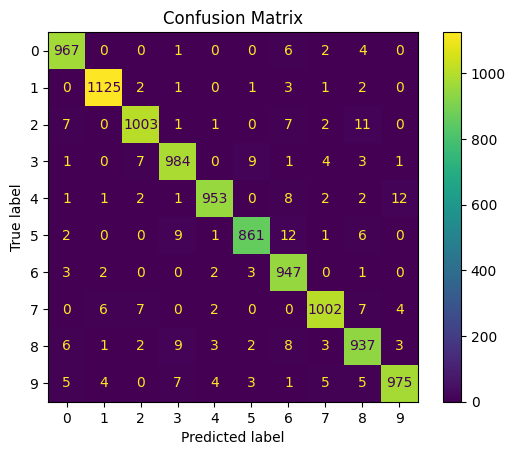

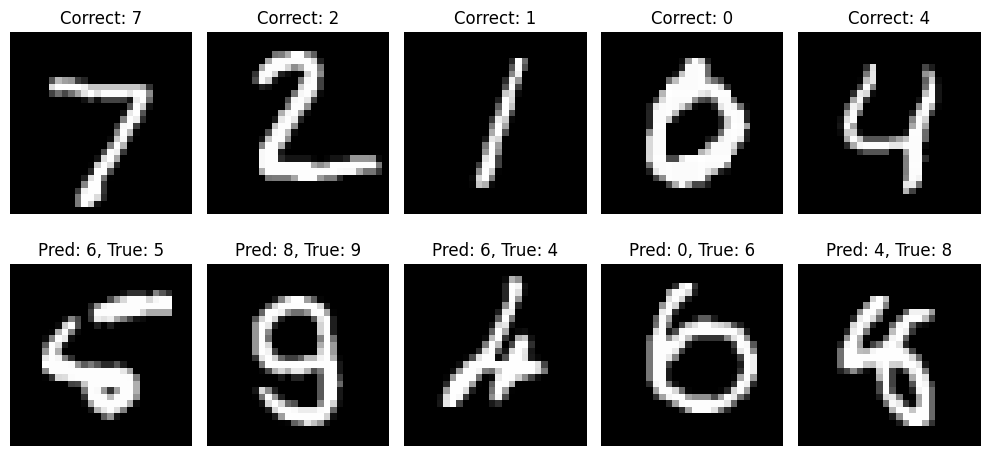

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Predictions
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()


# 3. Visualize Correct & Wrong Predictions

# reshape back to 28x28 for display
x_test_images = x_test.reshape(-1, 28, 28)

correct = []
wrong = []

for i in range(len(y_test)):
    if y_pred[i] == y_test[i] and len(correct) < 5:
        correct.append(i)
    elif y_pred[i] != y_test[i] and len(wrong) < 5:
        wrong.append(i)

# Plot
plt.figure(figsize=(10,5))

# Correct predictions
for i, idx in enumerate(correct):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test_images[idx], cmap='gray')
    plt.title(f"Correct: {y_pred[idx]}")
    plt.axis('off')

# Wrong predictions
for i, idx in enumerate(wrong):
    plt.subplot(2,5,i+6)
    plt.imshow(x_test_images[idx], cmap='gray')
    plt.title(f"Pred: {y_pred[idx]}, True: {y_test[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()